1. Imports

In [193]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import re, string, unicodedata # type: ignore
import warnings # type: ignore
warnings.filterwarnings('ignore')

import seaborn as sns # type: ignore
import matplotlib.pyplot as plt # type: ignore
import plotly.express as px # type: ignore

import nltk # type: ignore
from nltk.stem import WordNetLemmatizer # type: ignore
from nltk.tokenize import word_tokenize # type: ignore
from nltk.corpus import wordnet # type: ignore
from nltk.corpus import stopwords # type: ignore
from nltk.sentiment.vader import SentimentIntensityAnalyzer # type: ignore

from sklearn.feature_extraction.text import CountVectorizer # type: ignore
from wordcloud import WordCloud, STOPWORDS # type: ignore
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score # type: ignore
from sklearn.model_selection import train_test_split # type: ignore
from string import punctuation # type: ignore

2. Loading the dataset

In [155]:
%%time
df = pd.read_csv('/Users/treva.ogwang/Desktop/Codes/social_media/sentimentdataset.csv')

CPU times: user 3.28 ms, sys: 1.32 ms, total: 4.6 ms
Wall time: 4.22 ms


In [156]:
df.head(10)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
5,5,5,Feeling grateful for the little things in lif...,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9
6,6,6,Rainy days call for cozy blankets and hot coc...,Positive,2023-01-16 14:45:00,RainyDays,Facebook,#RainyDays #Cozy,10.0,20.0,Canada,2023,1,16,14
7,7,7,The new movie release is a must-watch! ...,Positive,2023-01-16 19:30:00,MovieBuff,Instagram,#MovieNight #MustWatch,15.0,30.0,USA,2023,1,16,19
8,8,8,Political discussions heating up on the timel...,Negative,2023-01-17 08:00:00,DebateTalk,Twitter,#Politics #Debate,30.0,60.0,USA,2023,1,17,8
9,9,9,Missing summer vibes and beach days. ...,Neutral,2023-01-17 12:20:00,BeachLover,Facebook,#Summer #BeachDays,18.0,35.0,Australia,2023,1,17,12


In [212]:
# Applying the VADER sentiment analysis to the 'Text' column
df['Vader_Sentiment'] = df['Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [216]:
# Convert Vader_Sentiment to numeric, setting errors='coerce' to handle non-numeric values
df['Vader_Sentiment'] = pd.to_numeric(df['Vader_Sentiment'], errors='coerce')

In [218]:
# Drop rows with NaN values in Vader_Sentiment (optional, depending on your use case)
df.dropna(subset=['Vader_Sentiment'], inplace=True)

In [220]:
# Converting the sentiment score to a fine-grained sentiment label
df['Vader_Sentiment'] = pd.cut(df['Vader_Sentiment'], bins=5, labels=['Very_Negative', 'Negative', 'Neutral', 'Positive', 'Very_Positive'])

In [222]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Cleaned_Text,Vader_Sentiment
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying beautiful day park,Very_Positive
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic terrible morning,Negative
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,finished amazing workout,Very_Positive
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited upcoming weekend getaway,Positive
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying new recipe dinner tonight,Neutral


In [223]:
df['Vader_Sentiment'].value_counts()

Vader_Sentiment
Very_Positive    273
Positive         163
Neutral          122
Negative          95
Very_Negative     79
Name: count, dtype: int64

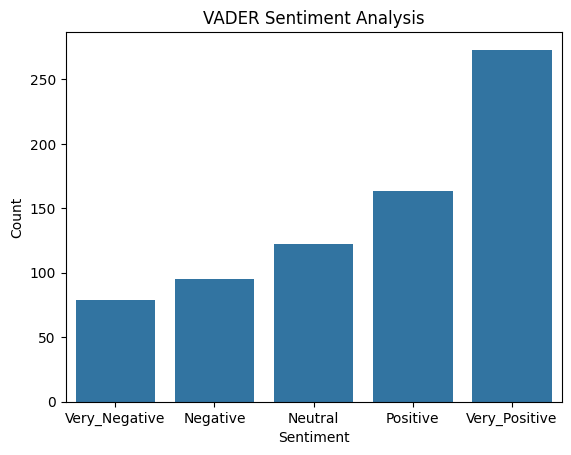

In [224]:
sns.countplot(x='Vader_Sentiment', data=df, order=['Very_Negative', 'Negative', 'Neutral', 'Positive', 'Very_Positive'])  
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('VADER Sentiment Analysis')
plt.show()

3. Data Overview

In [157]:
#Checking missing value
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [158]:
df['Text'].describe()

count                                                   732
unique                                                  707
top        A compassionate rain, tears of empathy fallin...
freq                                                      3
Name: Text, dtype: object

In [159]:
df['Platform'].describe()

count             732
unique              4
top        Instagram 
freq              258
Name: Platform, dtype: object

4. Data Cleaning

A) Checking for duplicates

In [160]:
# Finding and counting the number of fully duplicated rows
duplicate_rows = df[df.duplicated()]

print(f"Number of fully duplicate rows: {duplicate_rows.shape[0]}")

Number of fully duplicate rows: 0


B) Downloading the stop words

In [161]:
#Downloading the stopwords from nltk
nltk.download("stopwords")

#List of stop words 
stop_words = set(stopwords.words('english'))

#Displaying the stop words
print(stop_words)

{'herself', 'did', 'will', "shan't", 'after', 'my', 'ma', 'now', 'each', "needn't", 'most', 'an', 'any', 'hadn', 'himself', 'mightn', 'her', 'haven', 'you', 'been', "doesn't", 'his', 'too', 'does', 'theirs', 'me', "aren't", 'that', 'yourselves', 'by', 'have', 's', 'ourselves', "mightn't", 'having', 'their', 'from', "that'll", 'of', 've', 'doesn', "won't", 'had', 'm', "couldn't", 'because', 'was', 'were', 'do', 'but', "don't", 'wouldn', 'our', 'nor', 'own', 'while', 'under', 'above', 'y', 'about', 'he', 'them', "you'll", 'these', 'be', 'few', 'very', 'what', "you'd", 'until', 'yourself', 'couldn', 'i', 'its', 'the', "it's", 'a', "isn't", 'this', 'can', 'once', "weren't", 'and', "shouldn't", 'both', 'than', 'myself', 'no', 'with', "you're", 'down', 'shan', 'over', 'against', 'to', 'we', 'such', 'isn', 'between', 'am', 'some', "should've", 'aren', 'out', "didn't", "hadn't", "wasn't", 'ours', 'she', 'him', 'hers', 'on', 'd', 'below', 'ain', 'whom', 'll', 't', 'which', 'at', 'just', 'same',

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


C) Creating a function to clean the dataset.

In [162]:
#Creating a function to clean the dataset.

def clean_text(text):
    text = text.lower() #Convert text to lower-case
    text = re.sub(r'http\S+|www.\S+', '', text) #Removing URL
    text = re.sub(r'\d+', '', text) #Removing digits
    text = text.translate(str.maketrans('', '', string.punctuation)) #Removing punctuation
    text = text.strip() #Removing white spaces
    text = re.sub(r'@\S+', '', text) # Remove mentions (e.g., @username)
    text = re.sub(r'#\S+', '', text) # Remove hashtags (e.g., #hashtag)
    text = re.sub(r'[^a-z\s]', '', text)     # Remove non-alphabetic characters (punctuation and numbers)
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # Remove non-ASCII characters (including emojis)
    
    text = text.split() #Splitting the text
    text = [word for word in text if word not in stop_words] #Removing stop words
    text = ' '.join(text) #Joining the text
    
    return text

#Applying the function to the dataset and storing it in a new column named 'Cleaned_Text'
df['Cleaned_Text'] = df['Text'].astype(str).apply(clean_text)

df.head(10)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Cleaned_Text
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying beautiful day park
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic terrible morning
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,finished amazing workout
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited upcoming weekend getaway
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying new recipe dinner tonight
5,5,5,Feeling grateful for the little things in lif...,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9,feeling grateful little things life
6,6,6,Rainy days call for cozy blankets and hot coc...,Positive,2023-01-16 14:45:00,RainyDays,Facebook,#RainyDays #Cozy,10.0,20.0,Canada,2023,1,16,14,rainy days call cozy blankets hot cocoa
7,7,7,The new movie release is a must-watch! ...,Positive,2023-01-16 19:30:00,MovieBuff,Instagram,#MovieNight #MustWatch,15.0,30.0,USA,2023,1,16,19,new movie release mustwatch
8,8,8,Political discussions heating up on the timel...,Negative,2023-01-17 08:00:00,DebateTalk,Twitter,#Politics #Debate,30.0,60.0,USA,2023,1,17,8,political discussions heating timeline
9,9,9,Missing summer vibes and beach days. ...,Neutral,2023-01-17 12:20:00,BeachLover,Facebook,#Summer #BeachDays,18.0,35.0,Australia,2023,1,17,12,missing summer vibes beach days


D) Converting the Column "Platform to lowercase"

In [163]:
#Converting the string in the 'Platform' column to lower case
df['Platform'] = df['Platform'].str.lower()

# Remove leading and trailing white spaces from the 'Platform' column
df['Platform'] = df['Platform'].str.strip()

E) Dropping unnecessary columns in the data set that may not helpful in the analysis.

In [164]:
# Dropping the columns that are not necessary for the analysis
df_cleaned = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'User', 'Hashtags', 'Timestamp', 'Sentiment'])

df_cleaned.head(10)

,Text,Platform,Retweets,Likes,Country,Year,Month,Day,Hour,Cleaned_Text
0,Enjoying a beautiful day at the park! ...,twitter,15.0,30.0,USA,2023,1,15,12,enjoying beautiful day park
1,Traffic was terrible this morning. ...,twitter,5.0,10.0,Canada,2023,1,15,8,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,instagram,20.0,40.0,USA,2023,1,15,15,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,facebook,8.0,15.0,UK,2023,1,15,18,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,instagram,12.0,25.0,Australia,2023,1,15,19,trying new recipe dinner tonight
5,Feeling grateful for the little things in lif...,twitter,25.0,50.0,India,2023,1,16,9,feeling grateful little things life
6,Rainy days call for cozy blankets and hot coc...,facebook,10.0,20.0,Canada,2023,1,16,14,rainy days call cozy blankets hot cocoa
7,The new movie release is a must-watch! ...,instagram,15.0,30.0,USA,2023,1,16,19,new movie release mustwatch
8,Political discussions heating up on the timel...,twitter,30.0,60.0,USA,2023,1,17,8,political discussions heating timeline
9,Missing summer vibes and beach days. ...,facebook,18.0,35.0,Australia,2023,1,17,12,missing summer vibes beach days


F) Checking for Duplicates in the column "Cleaned_Text"

In [165]:
# Checking for duplicate values in column "Text"
duplicates = df_cleaned['Cleaned_Text'].duplicated()

# To see how many duplicates are in the 'Text' column
print(duplicates.sum())

26


In [166]:
# Remove duplicates from the 'Text' column
df_cleaned = df_cleaned.drop_duplicates(subset='Text', keep='first')

print("Duplicates removed")

Duplicates removed


In [167]:
# Find which rows are duplicates in the 'Cleaned_Text' column
duplicates = df_cleaned[df_cleaned['Cleaned_Text'].duplicated(keep=False)]

# Display the duplicate rows and their index
duplicates


,Text,Platform,Retweets,Likes,Country,Year,Month,Day,Hour,Cleaned_Text
238,"Wrapped in the cloak of emotional numbness, a...",instagram,10.0,20.0,Canada,2021,11,30,15,wrapped cloak emotional numbness shield storms...
246,"Wrapped in the cloak of emotional numbness, a ...",instagram,10.0,20.0,Canada,2021,11,30,15,wrapped cloak emotional numbness shield storms...


In [168]:
#Downloading the wordnet from nltk to help with the lematization.

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [169]:
lemmatizer = WordNetLemmatizer()

# Function to get the correct POS tag for lemmatization
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ  # Adjective
    elif tag.startswith('V'):
        return wordnet.VERB  # Verb
    elif tag.startswith('N'):
        return wordnet.NOUN  # Noun
    elif tag.startswith('R'):
        return wordnet.ADV  # Adverb
    else:
        return wordnet.NOUN  # Default to NOUN if unknown

# Function to lemmatize text with the correct POS tagging
def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)  # Tokenize the text
    tagged_tokens = nltk.pos_tag(tokens)  # Get POS tags for tokens
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged_tokens]  # Lemmatize each word with the correct POS tag
    return " ".join(lemmatized_words)


# Apply to your dataset
df_cleaned['Lemmatized_Text'] = df_cleaned['Cleaned_Text'].apply(lemmatize_text)

In [170]:
#Spcifying the order of the columns
columns_order = ['Text', 'Cleaned_Text', 'Lemmatized_Text', 'Platform', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

# Reordering the DataFrame
df_cleaned = df_cleaned[columns_order]

# Check the new column order
df_cleaned.head()

,Text,Cleaned_Text,Lemmatized_Text,Platform,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,enjoy beautiful day park,twitter,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,traffic terrible morning,traffic terrible morning,twitter,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,finished amazing workout,finish amaze workout,instagram,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,excited upcoming weekend getaway,facebook,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,try new recipe dinner tonight,instagram,12.0,25.0,Australia,2023,1,15,19


5. Exploratory Data Analysis

A)Checking for Imbalance

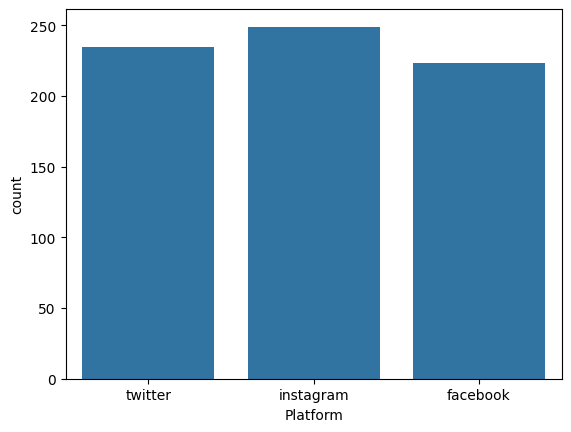

Platform
instagram    249
twitter      235
facebook     223
Name: count, dtype: int64


In [171]:
#Checking for Imbalance by checking the amount of text in each platform.
sns.countplot(x=df_cleaned['Platform'])
plt.show()
print(df_cleaned['Platform'].value_counts())

B) Word Cloud

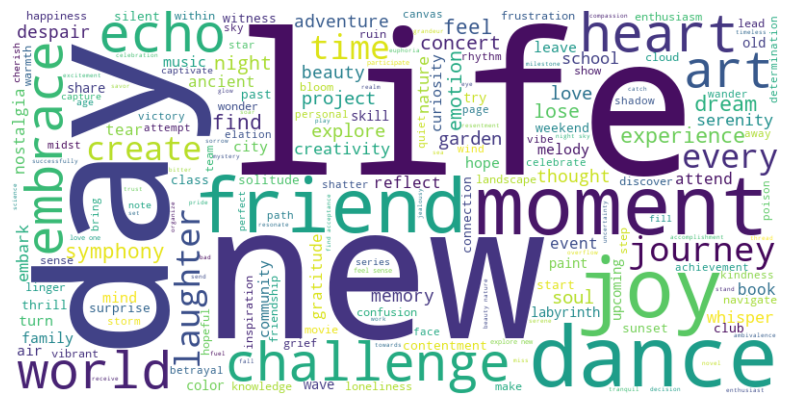

In [172]:
# Combining all text data into one large string
text_data = " ".join(df_cleaned['Lemmatized_Text'].dropna())  # Drop NaN values if any

# Generating the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axis
plt.show()

6. Sentiment Analysis using VADER

In [173]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [174]:
# Applying the VADER sentiment analysis to the 'Lemmatized_Text' column
df_cleaned['Vader_Sentiment'] = df_cleaned['Lemmatized_Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [175]:
df_cleaned.head()

,Text,Cleaned_Text,Lemmatized_Text,Platform,Retweets,Likes,Country,Year,Month,Day,Hour,Vader_Sentiment
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,enjoy beautiful day park,twitter,15.0,30.0,USA,2023,1,15,12,0.7964
1,Traffic was terrible this morning. ...,traffic terrible morning,traffic terrible morning,twitter,5.0,10.0,Canada,2023,1,15,8,-0.4767
2,Just finished an amazing workout! 💪 ...,finished amazing workout,finish amaze workout,instagram,20.0,40.0,USA,2023,1,15,15,0.5423
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,excited upcoming weekend getaway,facebook,8.0,15.0,UK,2023,1,15,18,0.3400
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,try new recipe dinner tonight,instagram,12.0,25.0,Australia,2023,1,15,19,0.0000


In [196]:
# Convert Vader_Sentiment to numeric, setting errors='coerce' to handle non-numeric values
df_cleaned_2['Vader_Sentiment'] = pd.to_numeric(df_cleaned_2['Vader_Sentiment'], errors='coerce')

In [198]:
# Drop rows with NaN values in Vader_Sentiment (optional, depending on your use case)
df_cleaned_2.dropna(subset=['Vader_Sentiment'], inplace=True)

In [200]:
# Dropping the columns that are not necessary for the analysis
df_cleaned_2 = df_cleaned.drop(columns=['Platform', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'])

# Converting the sentiment score to a fine-grained sentiment label
df_cleaned_2['Vader_Sentiment'] = pd.cut(df_cleaned_2['Vader_Sentiment'], bins=5, labels=['Very_Negative', 'Negative', 'Neutral', 'Positive', 'Very_Positive'])

In [201]:
df_cleaned_2.head(10)

,Text,Cleaned_Text,Lemmatized_Text,Vader_Sentiment
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,enjoy beautiful day park,Very_Positive
1,Traffic was terrible this morning. ...,traffic terrible morning,traffic terrible morning,Negative
2,Just finished an amazing workout! 💪 ...,finished amazing workout,finish amaze workout,Positive
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,excited upcoming weekend getaway,Positive
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,try new recipe dinner tonight,Neutral
5,Feeling grateful for the little things in lif...,feeling grateful little things life,feel grateful little thing life,Positive
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa,rainy day call cozy blanket hot cocoa,Neutral
7,The new movie release is a must-watch! ...,new movie release mustwatch,new movie release mustwatch,Neutral
8,Political discussions heating up on the timel...,political discussions heating timeline,political discussion heat timeline,Neutral
9,Missing summer vibes and beach days. ...,missing summer vibes beach days,miss summer vibe beach day,Neutral


In [204]:
#Creating a new column to store the length of the text.
df_cleaned_2['Length'] = df_cleaned_2['Lemmatized_Text'].apply(lambda x: len(x))

In [205]:
df_cleaned_2.head(10)

,Text,Cleaned_Text,Lemmatized_Text,Vader_Sentiment,Length
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,enjoy beautiful day park,Very_Positive,24
1,Traffic was terrible this morning. ...,traffic terrible morning,traffic terrible morning,Negative,24
2,Just finished an amazing workout! 💪 ...,finished amazing workout,finish amaze workout,Positive,20
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,excited upcoming weekend getaway,Positive,32
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,try new recipe dinner tonight,Neutral,29
5,Feeling grateful for the little things in lif...,feeling grateful little things life,feel grateful little thing life,Positive,31
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa,rainy day call cozy blanket hot cocoa,Neutral,37
7,The new movie release is a must-watch! ...,new movie release mustwatch,new movie release mustwatch,Neutral,27
8,Political discussions heating up on the timel...,political discussions heating timeline,political discussion heat timeline,Neutral,34
9,Missing summer vibes and beach days. ...,missing summer vibes beach days,miss summer vibe beach day,Neutral,26


In [209]:
#Printing distinct values in the 'Sentiment' column and how many times they appear
print(df['Sentiment'].value_counts())

Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Contentment        14
                   ..
Adrenaline          1
Harmony             1
ArtisticBurst       1
Radiance            1
Elegance            1
Name: count, Length: 279, dtype: int64


In [210]:
df_cleaned_2['Vader_Sentiment'].value_counts()

Vader_Sentiment
Very_Positive    242
Positive         176
Neutral          119
Very_Negative     85
Negative          85
Name: count, dtype: int64

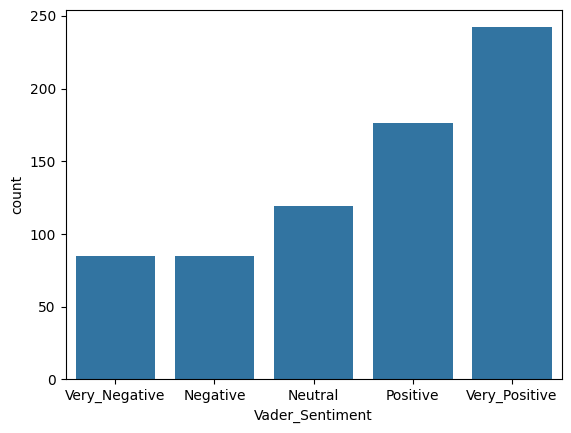

Vader_Sentiment
Very_Positive    242
Positive         176
Neutral          119
Very_Negative     85
Negative          85
Name: count, dtype: int64


In [211]:
sns.countplot(x=df_cleaned_2['Vader_Sentiment'])
plt.show()
print(df_cleaned_2['Vader_Sentiment'].value_counts())